In [14]:
import os
print("Current folder:", os.getcwd())
print("Files in data folder:", os.listdir('../data'))

Current folder: C:\Users\Shiva\Downloads\Task4\notebooks
Files in data folder: ['.ipynb_checkpoints', 'online_store_customer_data.csv']


Loaded! Shape: (2512, 11)


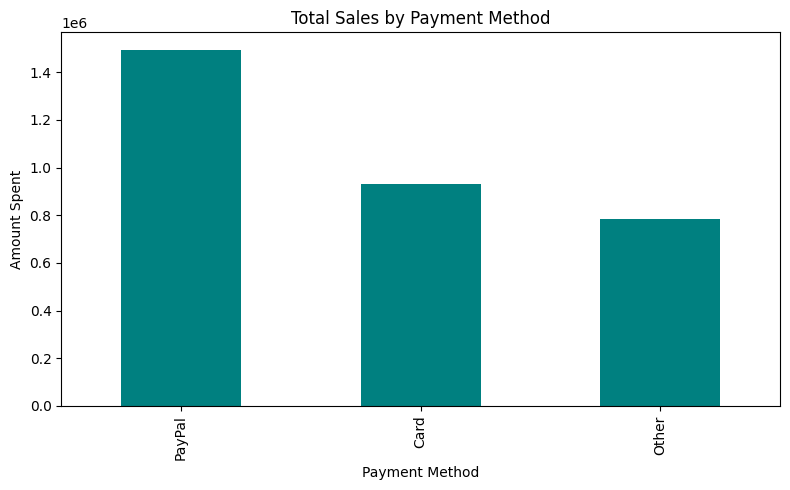

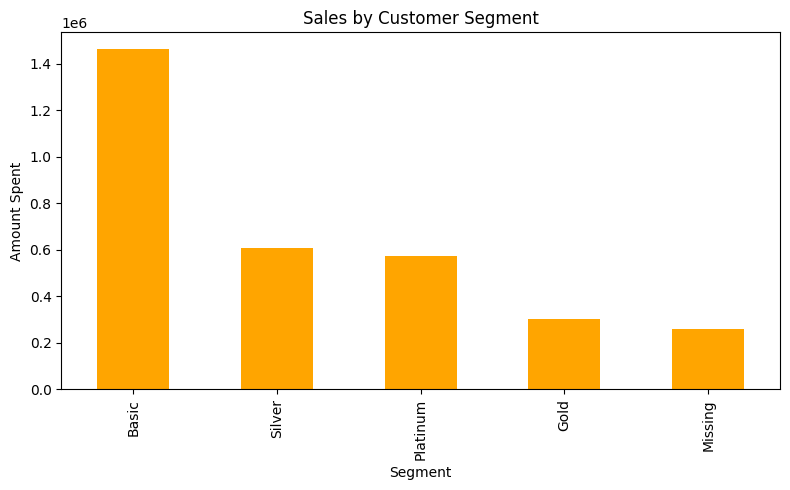

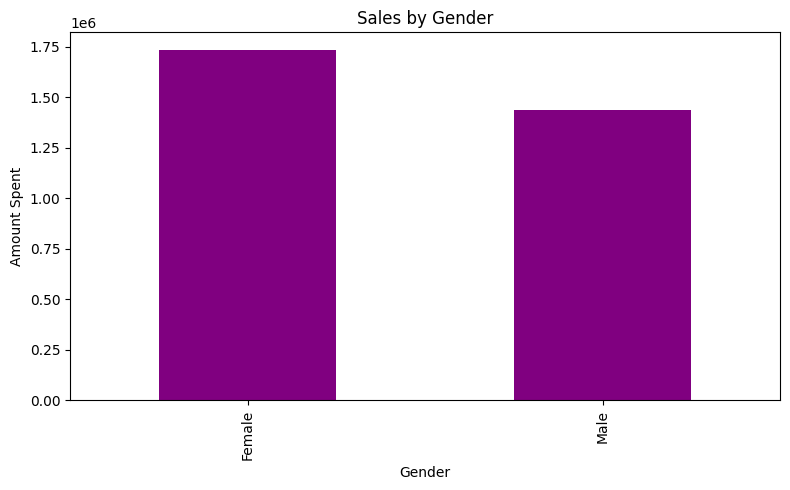

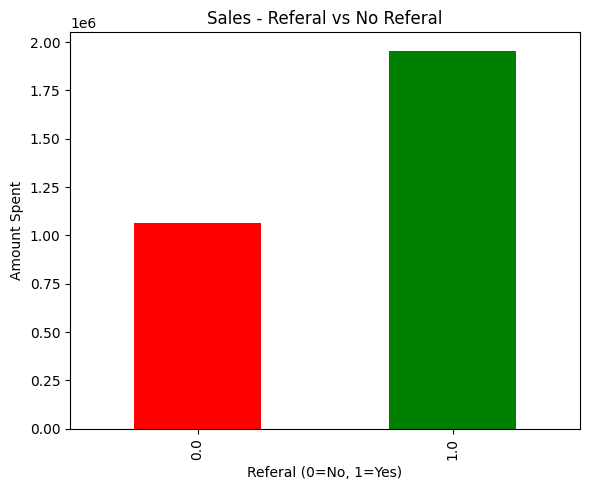

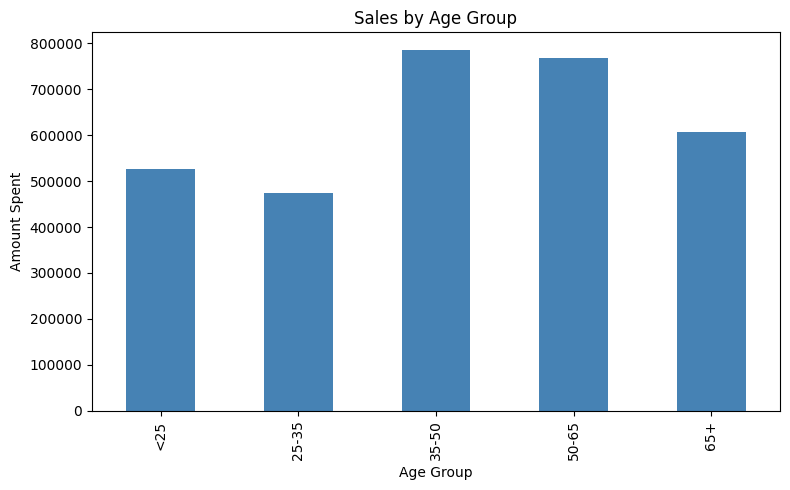

All charts saved successfully!


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../report', exist_ok=True)

df = pd.read_csv('../data/online_store_customer_data.csv')
print("Loaded! Shape:", df.shape)

df.dropna(subset=['Amount_spent', 'Payment_method', 'Segment'], inplace=True)
df.drop_duplicates(inplace=True)

channel_sales = df.groupby('Payment_method')['Amount_spent'].sum().sort_values(ascending=False)
segment_sales = df.groupby('Segment')['Amount_spent'].sum().sort_values(ascending=False)
gender_sales = df.groupby('Gender')['Amount_spent'].sum().sort_values(ascending=False)
referal_sales = df.groupby('Referal')['Amount_spent'].sum()

plt.figure(figsize=(8,5))
channel_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Amount Spent')
plt.tight_layout()
plt.savefig('../outputs/sales_by_channel.png')
plt.show()

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar', color='orange')
plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Amount Spent')
plt.tight_layout()
plt.savefig('../outputs/sales_by_segment.png')
plt.show()

plt.figure(figsize=(8,5))
gender_sales.plot(kind='bar', color='purple')
plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Amount Spent')
plt.tight_layout()
plt.savefig('../outputs/sales_by_gender.png')
plt.show()

plt.figure(figsize=(6,5))
referal_sales.plot(kind='bar', color=['red','green'])
plt.title('Sales - Referal vs No Referal')
plt.xlabel('Referal (0=No, 1=Yes)')
plt.ylabel('Amount Spent')
plt.tight_layout()
plt.savefig('../outputs/referal_analysis.png')
plt.show()

df['Age_Group'] = pd.cut(df['Age'],
                   bins=[0,25,35,50,65,100],
                   labels=['<25','25-35','35-50','50-65','65+'])
age_sales = df.groupby('Age_Group')['Amount_spent'].sum()

plt.figure(figsize=(8,5))
age_sales.plot(kind='bar', color='steelblue')
plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Amount Spent')
plt.tight_layout()
plt.savefig('../outputs/sales_by_age.png')
plt.show()

print("All charts saved successfully!")

In [16]:
report = """
BUSINESS INSIGHTS REPORT - ONLINE STORE MARKETING ANALYSIS
============================================================
Prepared by: Vasala Shivani
Date: 2026-06-27

1. DATASET OVERVIEW
-------------------
Total Transactions : {}
Total Revenue      : ${:.2f}
Average Spend      : ${:.2f}

2. SALES BY PAYMENT METHOD (MARKETING CHANNEL)
-----------------------------------------------
{}

3. SALES BY CUSTOMER SEGMENT
-----------------------------
{}

4. SALES BY GENDER
------------------
{}

5. REFERAL IMPACT
-----------------
{}

6. BUDGET RECOMMENDATIONS
--------------------------
- INCREASE budget for: {} (highest revenue channel)
- FOCUS on: {} (highest spending segment)
- TARGET: Referral customers (they spend more)
- AGE GROUP to target: 35-50 (highest spending group)

7. CONCLUSION
-------------
Based on EDA, the store should focus marketing budget on
the top performing payment channels and customer segments.
Referral programs show strong ROI and should be expanded.
============================================================
""".format(
    len(df),
    df['Amount_spent'].sum(),
    df['Amount_spent'].mean(),
    channel_sales.to_string(),
    segment_sales.to_string(),
    gender_sales.to_string(),
    referal_sales.to_string(),
    channel_sales.idxmax(),
    segment_sales.idxmax()
)

print(report)

with open('../report/business_insights_report.txt', 'w') as f:
    f.write(report)

print("Report saved successfully!")


BUSINESS INSIGHTS REPORT - ONLINE STORE MARKETING ANALYSIS
Prepared by: Vasala Shivani
Date: 2026-06-27

1. DATASET OVERVIEW
-------------------
Total Transactions : 2259
Total Revenue      : $3206857.83
Average Spend      : $1419.59

2. SALES BY PAYMENT METHOD (MARKETING CHANNEL)
-----------------------------------------------
Payment_method
PayPal    1493127.64
Card       930147.18
Other      783583.01

3. SALES BY CUSTOMER SEGMENT
-----------------------------
Segment
Basic       1461581.14
Silver       607833.04
Platinum     572386.89
Gold         304477.43
Missing      260579.33

4. SALES BY GENDER
------------------
Gender
Female    1733893.09
Male      1438001.72

5. REFERAL IMPACT
-----------------
Referal
0.0    1061705.81
1.0    1952487.68

6. BUDGET RECOMMENDATIONS
--------------------------
- INCREASE budget for: PayPal (highest revenue channel)
- FOCUS on: Basic (highest spending segment)
- TARGET: Referral customers (they spend more)
- AGE GROUP to target: 35-50 (highest